# Credit Risk Modeling: Static vs Sequential Approaches

Logistic Regression, Random Forest, XGBoost, LightGBM, and LSTM — binary default prediction on mobile money data.

## 1. Setup

In [ ]:
import sys
import os

# Ensure seqcredit_model package is importable from notebooks directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from seqcredit_model.credit_model import (
    CreditRiskDataLoader, LogisticRegressionModel,
    XGBoostModel, RandomForestModel, LightGBMModel,
    LSTMModel, HybridLSTMModel, ModelEvaluator, set_random_seeds
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

set_random_seeds(42)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('Setup complete.')

## 2. Data Exploration

In [ ]:
# Load raw data for exploration
df_features = pd.read_csv(os.path.join(project_root, 'data/user_features.csv'))
df_summaries = pd.read_csv(os.path.join(project_root, 'data/user_labels.csv'))

print(f'User features: {df_features.shape}')
print(f'User summaries: {df_summaries.shape}')
print(f'\nCredit risk label distribution (all users):')
print(df_summaries['credit_risk_label'].value_counts().sort_index())

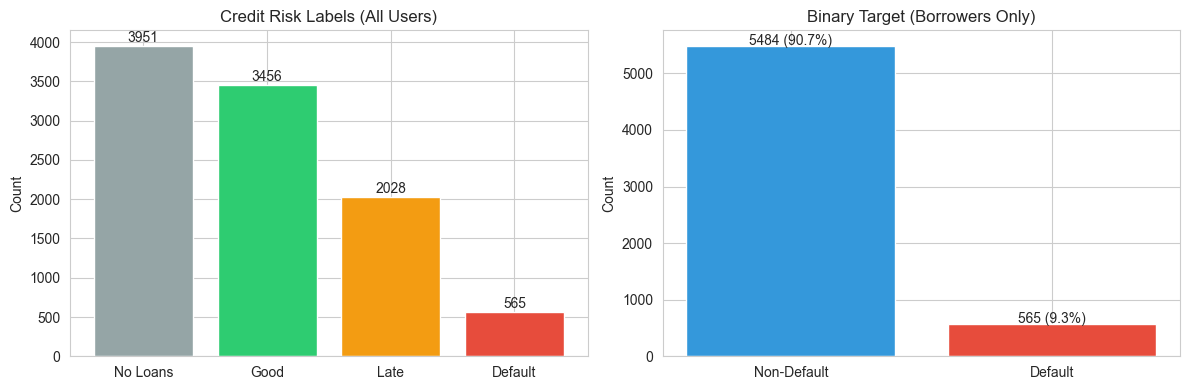


Total borrowers: 6049
Default rate: 0.093 (565 defaults)


In [4]:
# Visualize target distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# All users
labels_all = df_summaries['credit_risk_label'].value_counts().sort_index()
label_names = {-1: 'No Loans', 0: 'Good', 1: 'Late', 2: 'Default'}
ax1.bar([label_names[k] for k in labels_all.index], labels_all.values,
        color=['#95a5a6', '#2ecc71', '#f39c12', '#e74c3c'])
ax1.set_title('Credit Risk Labels (All Users)')
ax1.set_ylabel('Count')
for i, v in enumerate(labels_all.values):
    ax1.text(i, v + 50, str(v), ha='center')

# Borrowers only (binary target)
borrowers = df_summaries[df_summaries['credit_risk_label'] != -1]
binary = (borrowers['credit_risk_label'] == 2).astype(int)
counts = binary.value_counts().sort_index()
ax2.bar(['Non-Default', 'Default'], counts.values,
        color=['#3498db', '#e74c3c'])
ax2.set_title('Binary Target (Borrowers Only)')
ax2.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax2.text(i, v + 20, f'{v} ({v/len(borrowers)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

print(f'\nTotal borrowers: {len(borrowers)}')
print(f'Default rate: {binary.mean():.3f} ({binary.sum()} defaults)')

In [5]:
# Credit archetype distribution among borrowers
print('Credit archetypes (borrowers):')
print(borrowers['credit_archetype'].value_counts())

Credit archetypes (borrowers):
credit_archetype
responsible_borrower    3511
occasional_borrower     1504
risky_borrower           824
defaulter                210
Name: count, dtype: int64


## 3. Data Preparation

In [ ]:
# Initialize data loader with paths relative to project root
loader = CreditRiskDataLoader(
    features_path=os.path.join(project_root, 'data/user_features.csv'),
    summaries_path=os.path.join(project_root, 'data/user_labels.csv'),
    transactions_dir=os.path.join(project_root, 'data/user_transactions'),
)

# Prepare static data splits
static_data = loader.prepare_static_splits()

print(f"Training samples: {len(static_data['y_train'])}")
print(f"Test samples: {len(static_data['y_test'])}")
print(f"Default rate (train): {static_data['y_train'].mean():.4f}")
print(f"Default rate (test): {static_data['y_test'].mean():.4f}")
print(f"Features: {len(static_data['feature_names'])}")
print(f"Scale pos weight: {loader.get_scale_pos_weight():.2f}")
print(f"\nFeature list:")
for i, name in enumerate(static_data['feature_names']):
    print(f"  {i+1:2d}. {name}")

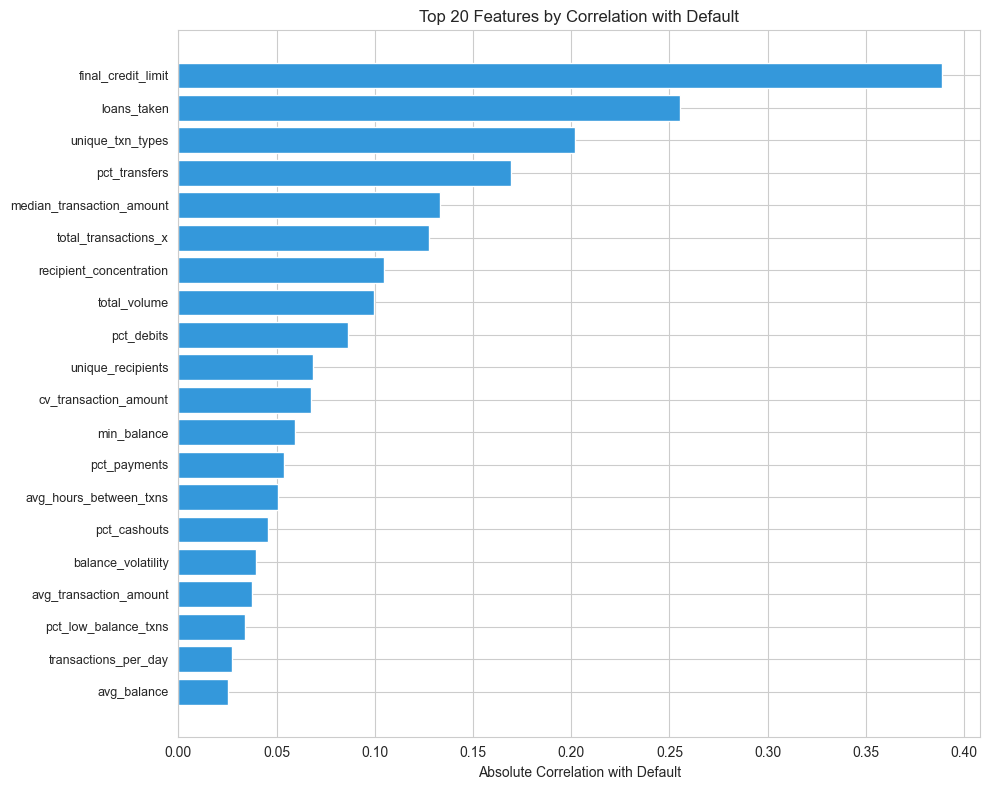

In [7]:
# Feature correlation with target (top features)
X_train_df = static_data['X_train'].copy()
X_train_df['default'] = static_data['y_train']
correlations = X_train_df.corr()['default'].drop('default').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_corr = correlations.head(20)
ax.barh(range(len(top_corr)), top_corr.values, color='#3498db')
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index, fontsize=9)
ax.set_xlabel('Absolute Correlation with Default')
ax.set_title('Top 20 Features by Correlation with Default')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Logistic Regression

In [8]:
# Train Logistic Regression
lr_model = LogisticRegressionModel(class_weight='balanced')
lr_model.fit(static_data['X_train_scaled'], static_data['y_train'])

# Cross-validation
print('Logistic Regression - 5-Fold Cross-Validation:')
lr_cv = lr_model.cross_validate(static_data['X_train_scaled'], static_data['y_train'])
for metric, values in lr_cv.items():
    print(f'  {metric}: {np.mean(values):.4f} +/- {np.std(values):.4f}')

Logistic Regression - 5-Fold Cross-Validation:
  auc_roc: 0.9784 +/- 0.0046
  auc_pr: 0.8644 +/- 0.0242
  f1: 0.6491 +/- 0.0236
  accuracy: 0.9054 +/- 0.0081


In [9]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Test predictions
lr_proba = lr_model.predict_proba(static_data['X_test_scaled'])

print('Logistic Regression - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(static_data["y_test"], lr_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(static_data["y_test"], lr_proba):.4f}')

Logistic Regression - Test Set Performance:
  AUC-ROC: 0.9717
  AUC-PR: 0.8134


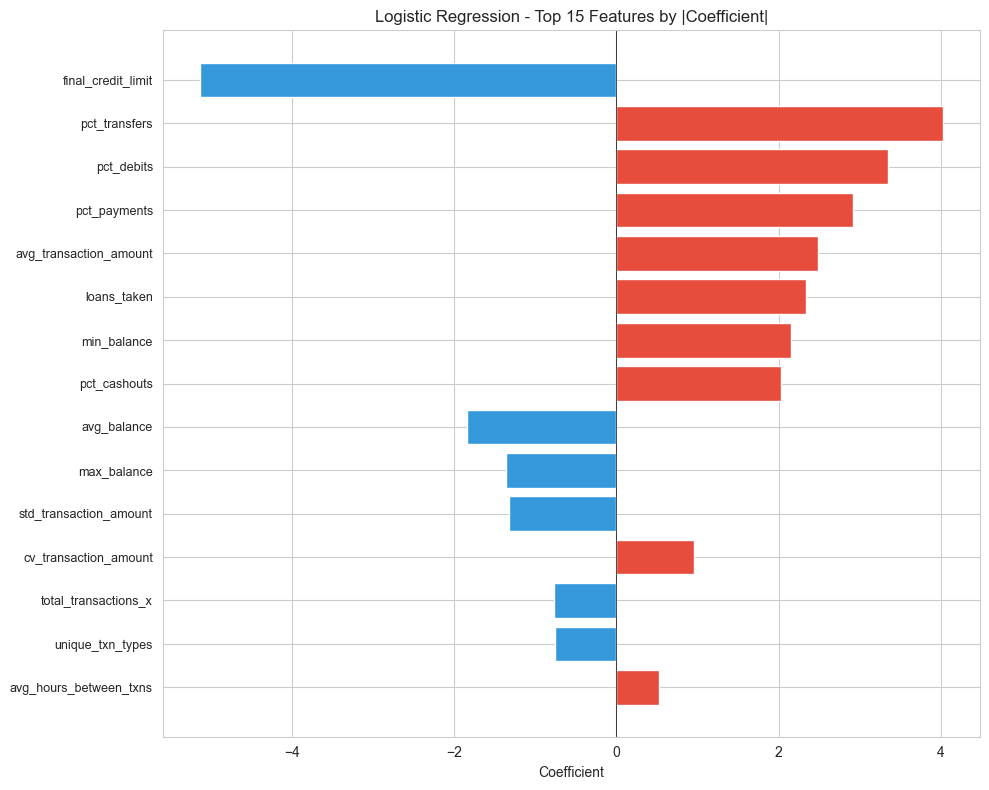

Red = increases default probability, Blue = decreases


In [10]:
# Feature coefficients
lr_coefs = lr_model.get_coefficients(static_data['feature_names'])

fig, ax = plt.subplots(figsize=(10, 8))
top_coefs = lr_coefs.head(15)
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top_coefs['coefficient']]
ax.barh(range(len(top_coefs)), top_coefs['coefficient'], color=colors)
ax.set_yticks(range(len(top_coefs)))
ax.set_yticklabels(top_coefs['feature'], fontsize=9)
ax.set_xlabel('Coefficient')
ax.set_title('Logistic Regression - Top 15 Features by |Coefficient|')
ax.invert_yaxis()
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Red = increases default probability, Blue = decreases')

## 5. XGBoost Classifier

In [11]:
# Train XGBoost — carve a validation split from training data (no test leakage)
from sklearn.model_selection import train_test_split as tts
X_tr, X_val_xgb, y_tr, y_val_xgb = tts(
    static_data['X_train_scaled'], static_data['y_train'],
    test_size=0.15, stratify=static_data['y_train'], random_state=42
)
xgb_model = XGBoostModel(scale_pos_weight=loader.get_scale_pos_weight())
xgb_model.fit(X_tr, y_tr, X_val=X_val_xgb, y_val=y_val_xgb)

# Cross-validation
print('XGBoost - 5-Fold Cross-Validation:')
xgb_cv = xgb_model.cross_validate(static_data['X_train_scaled'], static_data['y_train'])
for metric, values in xgb_cv.items():
    print(f'  {metric}: {np.mean(values):.4f} +/- {np.std(values):.4f}')

XGBoost - 5-Fold Cross-Validation:
  auc_roc: 0.9595 +/- 0.0086
  auc_pr: 0.7565 +/- 0.0333
  f1: 0.6559 +/- 0.0310
  accuracy: 0.9279 +/- 0.0067


In [12]:
# Test predictions
xgb_proba = xgb_model.predict_proba(static_data['X_test_scaled'])

print('XGBoost - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(static_data["y_test"], xgb_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(static_data["y_test"], xgb_proba):.4f}')

XGBoost - Test Set Performance:
  AUC-ROC: 0.9586
  AUC-PR: 0.7461


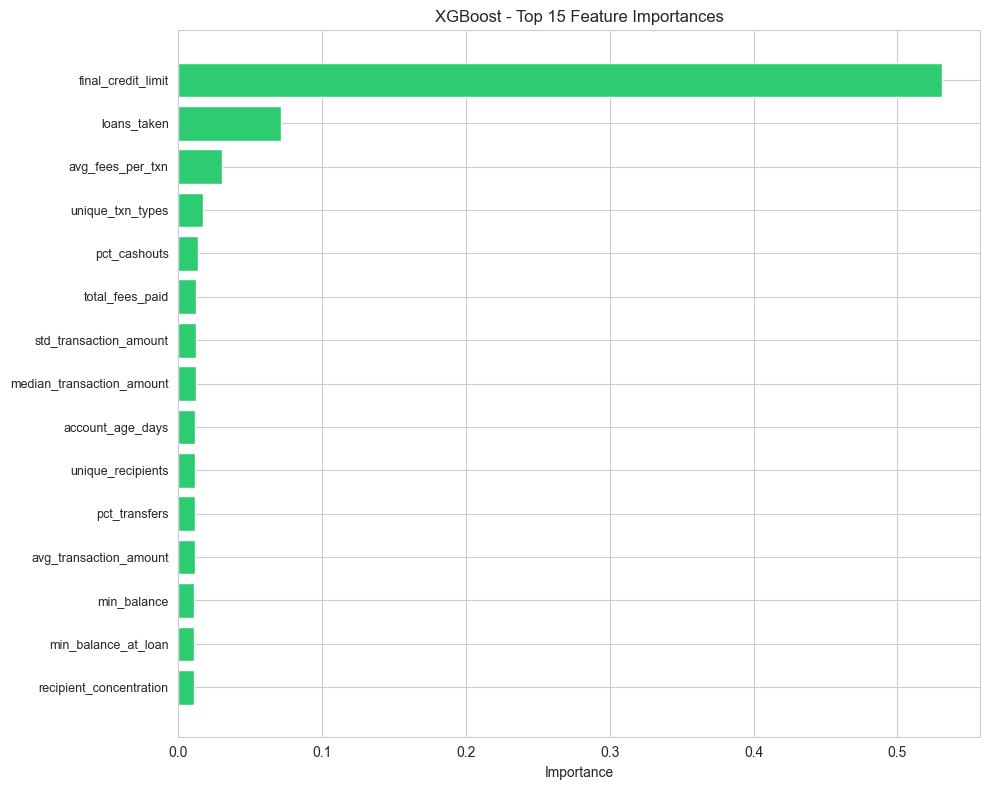

In [13]:
# Feature importance
xgb_importance = xgb_model.get_feature_importance(static_data['feature_names'])

fig, ax = plt.subplots(figsize=(10, 8))
top_imp = xgb_importance.head(15)
ax.barh(range(len(top_imp)), top_imp['importance'], color='#2ecc71')
ax.set_yticks(range(len(top_imp)))
ax.set_yticklabels(top_imp['feature'], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('XGBoost - Top 15 Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Random Forest

In [ ]:
rf_model = RandomForestModel(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced'
)
rf_model.fit(static_data['X_train_scaled'], static_data['y_train'])

print('Random Forest - 5-Fold Cross-Validation:')
rf_cv = rf_model.cross_validate(static_data['X_train_scaled'], static_data['y_train'])
for metric, values in rf_cv.items():
    print(f'  {metric}: {np.mean(values):.4f} +/- {np.std(values):.4f}')

rf_proba = rf_model.predict_proba(static_data['X_test_scaled'])

print('\nRandom Forest - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(static_data["y_test"], rf_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(static_data["y_test"], rf_proba):.4f}')

rf_importance = rf_model.get_feature_importance(static_data['feature_names'])
fig, ax = plt.subplots(figsize=(10, 8))
top_imp = rf_importance.head(15)
ax.barh(range(len(top_imp)), top_imp['importance'], color='#9b59b6')
ax.set_yticks(range(len(top_imp)))
ax.set_yticklabels(top_imp['feature'], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('Random Forest - Top 15 Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. LightGBM

In [ ]:
from sklearn.model_selection import train_test_split as tts

X_tr, X_val, y_tr, y_val = tts(
    static_data['X_train_scaled'], static_data['y_train'],
    test_size=0.15, stratify=static_data['y_train'], random_state=42
)

lgbm_model = LightGBMModel(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    num_leaves=31,
    class_weight='balanced'
)
lgbm_model.fit(X_tr, y_tr, X_val=X_val, y_val=y_val)

print('\nLightGBM - 5-Fold Cross-Validation:')
lgbm_cv = lgbm_model.cross_validate(static_data['X_train_scaled'], static_data['y_train'])
for metric, values in lgbm_cv.items():
    print(f'  {metric}: {np.mean(values):.4f} +/- {np.std(values):.4f}')

lgbm_proba = lgbm_model.predict_proba(static_data['X_test_scaled'])

print('\nLightGBM - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(static_data["y_test"], lgbm_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(static_data["y_test"], lgbm_proba):.4f}')

lgbm_importance = lgbm_model.get_feature_importance(static_data['feature_names'])
fig, ax = plt.subplots(figsize=(10, 8))
top_imp = lgbm_importance.head(15)
ax.barh(range(len(top_imp)), top_imp['importance'], color='#f39c12')
ax.set_yticks(range(len(top_imp)))
ax.set_yticklabels(top_imp['feature'], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('LightGBM - Top 15 Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. LSTM Models

Two architectures compared:
- **Sequential LSTM** — transaction sequences only
- **Hybrid LSTM** — sequences fused with static user features (early fusion)

In [ ]:
# LSTM data preparation — builds sequence + static arrays aligned to the exact
# same train/test user split used by the static models (via loader._train/test_user_ids)
from seqcredit_model.feature_engineering import TemporalTransactionFeatureEngineer
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.preprocessing.sequence import pad_sequences
from pathlib import Path

# Load sequences (used for feature_names reference; cache rebuilt if missing)
seq_data = loader.load_sequences(
    max_seq_len=100,
    cache_path=os.path.join(project_root, 'data/lstm_sequences.npz'),
)

# Reconstruct scaled static features for all borrowers (same feature set as static_data)
df_features_raw = pd.read_csv(os.path.join(project_root, 'data/user_features.csv'))
df_summaries_raw = pd.read_csv(os.path.join(project_root, 'data/user_labels.csv'))
df_merged = df_features_raw.merge(df_summaries_raw, on='user_id', how='inner')
df_merged = df_merged[df_merged['credit_risk_label'] != -1].copy()
df_merged['default'] = (df_merged['credit_risk_label'] == 2).astype(int)
df_merged = loader._engineer_loan_features(df_merged)

drop_cols = ['user_id', 'credit_risk_label', 'credit_archetype', 'default', 'gen_txn_count']
feature_cols = [c for c in df_merged.columns if c not in drop_cols]
X_all_lstm = StandardScaler().fit_transform(df_merged[feature_cols].values)
y_all_lstm = df_merged['default'].values
user_ids_lstm = df_merged['user_id'].values
user_to_idx = {uid: i for i, uid in enumerate(user_ids_lstm)}

transactions_path = Path(project_root) / 'data' / 'user_transactions'
engineer = TemporalTransactionFeatureEngineer()

def build_hybrid_data(user_id_set, max_seq_len=100):
    """Build aligned (sequence, static, label) arrays for a set of user IDs."""
    seq_list, static_list, label_list = [], [], []
    for uid in user_id_set:
        if uid not in user_to_idx:
            continue
        idx = user_to_idx[uid]
        filepath = transactions_path / f'{uid}.csv'
        if not filepath.exists():
            continue
        try:
            df_user = pd.read_csv(filepath)
            if df_user.empty or len(df_user) < 2:
                continue
            df_user['is_loan_disbursement'] = (df_user['TRANS. TYPE'] == 'CREDIT').astype(int)
            df_user['is_loan_repayment'] = (df_user['TRANS. TYPE'] == 'LOAN_REPAYMENT').astype(int)
            df_feat = engineer.extract_all_features(df_user)
            available_cols = [c for c in seq_data['feature_names'] if c in df_feat.columns]
            seq = df_feat[available_cols].values.astype(np.float32)
            seq = np.nan_to_num(seq, nan=0.0, posinf=0.0, neginf=0.0)
            seq_list.append(seq)
            static_list.append(X_all_lstm[idx])
            label_list.append(y_all_lstm[idx])
        except Exception:
            continue
    X_seq = pad_sequences(seq_list, maxlen=max_seq_len, padding='pre',
                          truncating='pre', dtype='float32', value=0.0)
    return X_seq, np.array(static_list), np.array(label_list)

print("Building training data...")
X_train_seq, X_train_static_lstm, y_train_lstm = build_hybrid_data(loader._train_user_ids)
print("Building test data...")
X_test_seq, X_test_static_lstm, y_test_lstm = build_hybrid_data(loader._test_user_ids)

print(f"\nTrain: seq {X_train_seq.shape}, static {X_train_static_lstm.shape}")
print(f"Test:  seq {X_test_seq.shape}, static {X_test_static_lstm.shape}")
print(f"Default rate — train: {y_train_lstm.mean():.4f}, test: {y_test_lstm.mean():.4f}")
assert len(y_test_lstm) == len(static_data['y_test']), \
    f"Test set size mismatch: LSTM {len(y_test_lstm)} vs static {len(static_data['y_test'])}"
print("Test set alignment confirmed.")

### 8a. Sequential LSTM

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_lstm)
weights = compute_class_weight('balanced', classes=classes, y=y_train_lstm)
class_weights_lstm = dict(zip(classes.astype(int), weights))
print(f'Class weights: {class_weights_lstm}')

lstm_model = LSTMModel(
    lstm_units_1=32,
    lstm_units_2=16,
    dense_units=8,
    dropout_rate=0.4,
    learning_rate=0.0005,
)
lstm_model.build_model((X_train_seq.shape[1], X_train_seq.shape[2]))
lstm_model.model.summary()

lstm_history = lstm_model.fit(
    X_train_seq, y_train_lstm,
    epochs=100, batch_size=32,
    class_weight=class_weights_lstm,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(lstm_history.history['loss'], label='Train Loss')
ax1.plot(lstm_history.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Sequential LSTM - Training Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(lstm_history.history['auc'], label='Train AUC')
ax2.plot(lstm_history.history['val_auc'], label='Val AUC')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
ax2.set_title('Sequential LSTM - Training AUC')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

lstm_proba = lstm_model.predict_proba(X_test_seq)

print('Sequential LSTM - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(y_test_lstm, lstm_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(y_test_lstm, lstm_proba):.4f}')
print()
print(classification_report(y_test_lstm, (lstm_proba >= 0.5).astype(int),
                             target_names=['Non-Default', 'Default']))

### 8b. Hybrid LSTM

In [ ]:
hybrid_model = HybridLSTMModel(
    lstm_units_1=32,
    lstm_units_2=16,
    dense_units=16,
    dropout_rate=0.4,
    learning_rate=0.0005,
)
hybrid_model.build_model((X_train_seq.shape[1], X_train_seq.shape[2]),
                         X_train_static_lstm.shape[1])
hybrid_model.model.summary()

hybrid_history = hybrid_model.fit(
    X_train_seq, X_train_static_lstm, y_train_lstm,
    epochs=100, batch_size=32,
    class_weight=class_weights_lstm,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(hybrid_history.history['loss'], label='Train Loss')
ax1.plot(hybrid_history.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Hybrid LSTM - Training Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(hybrid_history.history['auc'], label='Train AUC')
ax2.plot(hybrid_history.history['val_auc'], label='Val AUC')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
ax2.set_title('Hybrid LSTM - Training AUC')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
hybrid_proba = hybrid_model.predict_proba(X_test_seq, X_test_static_lstm)

print('Hybrid LSTM - Test Set Performance:')
print(f'  AUC-ROC: {roc_auc_score(y_test_lstm, hybrid_proba):.4f}')
print(f'  AUC-PR: {average_precision_score(y_test_lstm, hybrid_proba):.4f}')
print()
print(classification_report(y_test_lstm, (hybrid_proba >= 0.5).astype(int),
                             target_names=['Non-Default', 'Default']))

## 9. Model Comparison

In [ ]:
# All models evaluated on y_test_lstm (same users as static models — confirmed by assertion above)
evaluator = ModelEvaluator(y_test_lstm)
evaluator.add_model('Logistic Regression', lr_proba)
evaluator.add_model('XGBoost', xgb_proba)
evaluator.add_model('Random Forest', rf_proba)
evaluator.add_model('LightGBM', lgbm_proba)
evaluator.add_model('Sequential LSTM', lstm_proba)
evaluator.add_model('Hybrid LSTM', hybrid_proba)

comparison = evaluator.get_comparison_table()
print('\nModel Comparison (Test Set):')
print(comparison.round(4).to_string())

In [ ]:
# Cross-validation comparison (static models only; LSTM uses single split)
cv_results = {}
for name, cv in [('Logistic Regression', lr_cv), ('XGBoost', xgb_cv),
                 ('Random Forest', rf_cv), ('LightGBM', lgbm_cv)]:
    cv_results[name] = {
        metric: f"{np.mean(values):.4f} +/- {np.std(values):.4f}"
        for metric, values in cv.items()
    }

cv_df = pd.DataFrame(cv_results).T
print('\nCross-Validation Results (5-Fold, static models):')
print(cv_df.to_string())

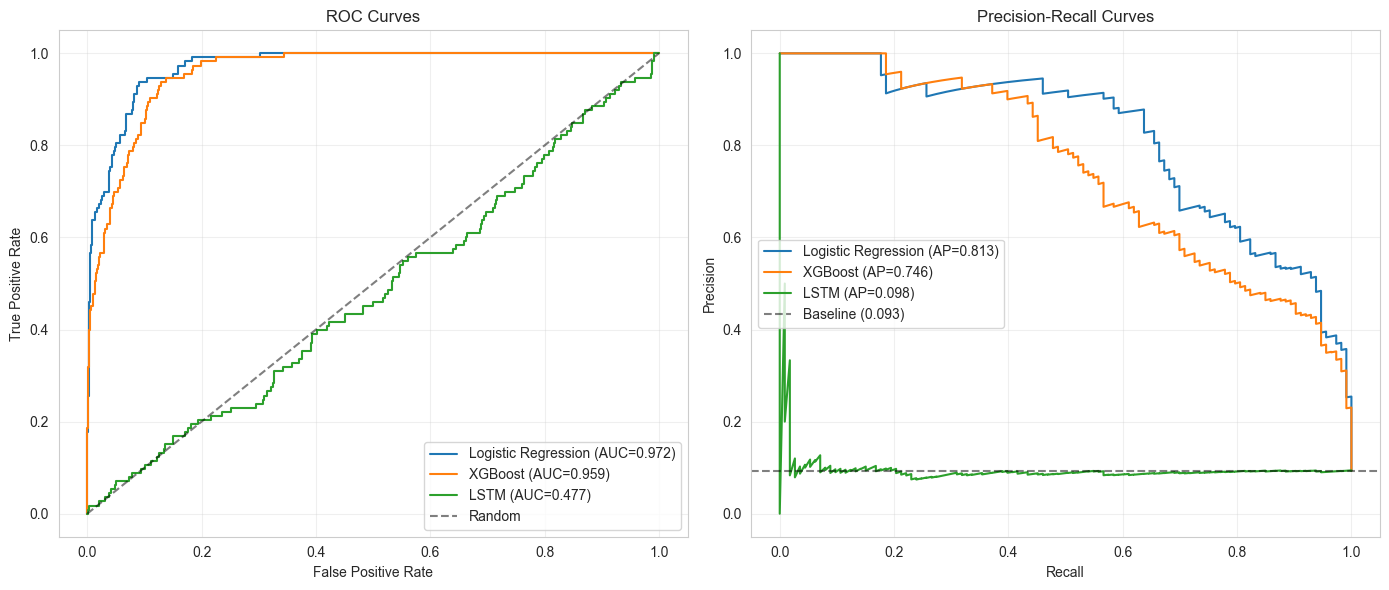

In [21]:
# ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
evaluator.plot_roc_curves(ax=ax1)
evaluator.plot_pr_curves(ax=ax2)
plt.tight_layout()
plt.show()

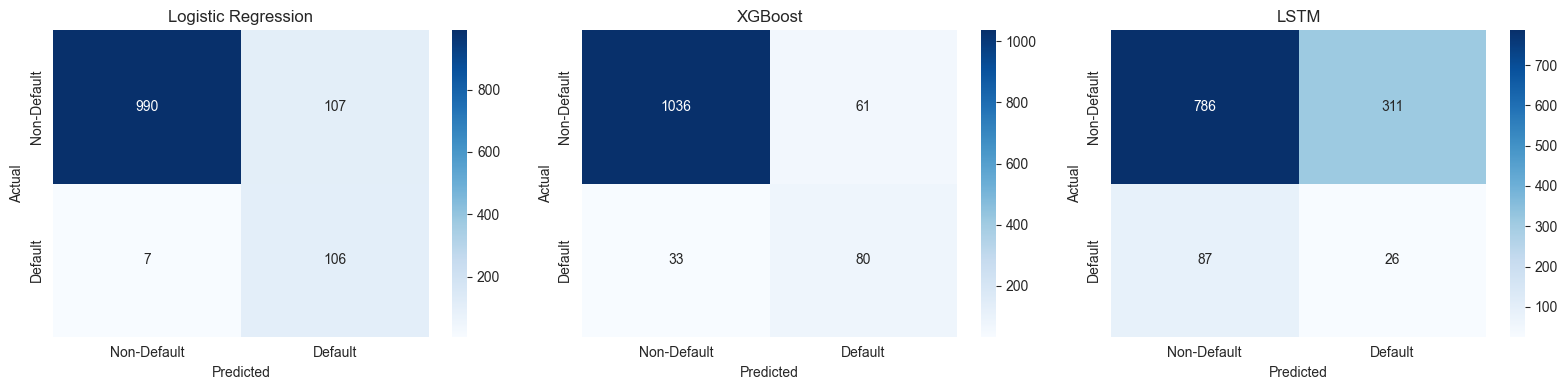

In [22]:
# Confusion matrices
evaluator.plot_confusion_matrices(figsize=(16, 4))
plt.show()

In [ ]:
# Calibration curves
from sklearn.calibration import CalibrationDisplay
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba in [('LR', lr_proba), ('XGBoost', xgb_proba),
                    ('RF', rf_proba), ('LightGBM', lgbm_proba),
                    ('Seq LSTM', lstm_proba), ('Hybrid LSTM', hybrid_proba)]:
    CalibrationDisplay.from_predictions(
        y_test_lstm, proba, n_bins=10, ax=ax, name=name
    )
ax.set_title('Calibration Curves')
plt.tight_layout()
plt.show()

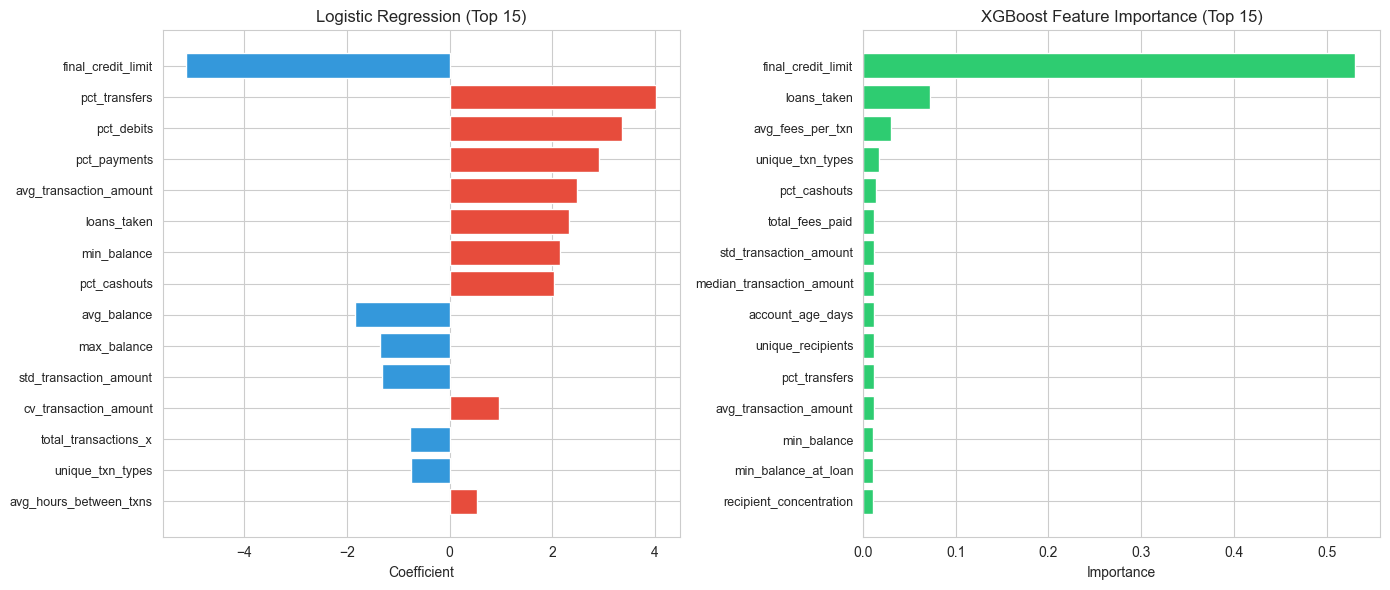

In [24]:
# Feature importance comparison (LR vs XGBoost)
evaluator.plot_feature_importance_comparison(
    lr_coefs, xgb_importance, top_n=15
)
plt.show()

In [ ]:
# Threshold analysis for each model
model_names = ['Logistic Regression', 'XGBoost', 'Random Forest', 'LightGBM',
               'Sequential LSTM', 'Hybrid LSTM']
fig, axes = plt.subplots(1, len(model_names), figsize=(6 * len(model_names), 5))
for ax, name in zip(axes, model_names):
    evaluator.plot_threshold_analysis(name, ax=ax)
plt.tight_layout()
plt.show()

In [26]:
# Classification reports
evaluator.print_classification_reports()


  Logistic Regression
              precision    recall  f1-score   support

 Non-Default       0.99      0.90      0.95      1097
     Default       0.50      0.94      0.65       113

    accuracy                           0.91      1210
   macro avg       0.75      0.92      0.80      1210
weighted avg       0.95      0.91      0.92      1210


  XGBoost
              precision    recall  f1-score   support

 Non-Default       0.97      0.94      0.96      1097
     Default       0.57      0.71      0.63       113

    accuracy                           0.92      1210
   macro avg       0.77      0.83      0.79      1210
weighted avg       0.93      0.92      0.93      1210


  LSTM
              precision    recall  f1-score   support

 Non-Default       0.90      0.72      0.80      1097
     Default       0.08      0.23      0.12       113

    accuracy                           0.67      1210
   macro avg       0.49      0.47      0.46      1210
weighted avg       0.82      0.6

## 10. Analysis

- **AUC-PR** is the primary metric given ~11% default rate (class imbalance).
- **Static models** (LR, RF, XGBoost, LightGBM) operate on 40 aggregate features; LightGBM and RF typically lead this group.
- **Sequential LSTM** uses only per-transaction sequences — captures temporal patterns but loses aggregate context.
- **Hybrid LSTM** fuses both: LSTM-encoded sequences concatenated with static features before the output layer. This is the most expressive architecture.
- Balance-related features dominate importance rankings across all static models.

In [27]:
# Save comparison table
comparison.to_csv(os.path.join(project_root, 'data/model_comparison.csv'))
print('Comparison table saved to data/model_comparison.csv')

Comparison table saved to data/model_comparison.csv
